<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 7 · SOLUCIÓN Ejercicio 1 — Titanic con Decision Tree y Random Forest</h1>
<h3>Análisis paso a paso</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · SkillNest
</div>
<br/>

Notebook de referencia. Acá ejecuto el ejercicio completo con los análisis que espero que los estudiantes hagan en sus entregas.

## Contexto

El 15 de abril de 1912 el RMS Titanic se hundió en su viaje inaugural. De las 2.224 personas a bordo murieron más de 1.500. La política oficial fue "mujeres y niños primero", pero también jugaron factores socioeconómicos: la clase del pasaje, la ubicación de los camarotes, la edad, las redes familiares.

La pregunta de negocio acá no es solo si podemos predecir quién sobrevive, sino también explicar QUÉ factores determinaron el destino de cada pasajero. Es una especie de autopsia social de la tragedia.

Dataset: 891 pasajeros con 12 features (clase, sexo, edad, familia a bordo, tarifa, puerto de embarque, etc.) y target binario `Survived` (0=murió, 1=sobrevivió).

## Setup y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])  # 'Cabin' tiene 77% nulos

# Definir X, y, columnas
X = df.drop(columns=['Survived'])
y = df['Survived']
cols_num = ['Age', 'SibSp', 'Parch', 'Fare']
cols_cat = ['Pclass', 'Sex', 'Embarked']

# Pipeline de preprocesamiento (reutilizable)
preproc = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), cols_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cols_cat)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Shape: {df.shape} | Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Tasa de supervivencia general: {y.mean()*100:.1f}%')

Shape: (891, 8) | Train: (712, 7) | Test: (179, 7)
Tasa de supervivencia general: 38.4%


## Parte A — Decision Tree controlado (max_depth=3) + Comparación con árbol sin límite

In [2]:
# Árbol pequeño (interpretable)
pipe_dt3 = Pipeline([('prep', preproc),
                      ('mod',  DecisionTreeClassifier(max_depth=3, random_state=42))])
pipe_dt3.fit(X_train, y_train)

# Árbol sin límite (overfit garantizado)
pipe_dt_full = Pipeline([('prep', preproc),
                          ('mod',  DecisionTreeClassifier(max_depth=None, random_state=42))])
pipe_dt_full.fit(X_train, y_train)

filas = []
for nombre, m in [('DT (max_depth=3)', pipe_dt3), ('DT (sin límite)', pipe_dt_full)]:
    filas.append({
        'Modelo': nombre,
        'Acc TRAIN': m.score(X_train, y_train),
        'Acc TEST':  m.score(X_test, y_test),
        'Brecha':    m.score(X_train, y_train) - m.score(X_test, y_test)
    })
print(pd.DataFrame(filas).set_index('Modelo').round(4))

                  Acc TRAIN  Acc TEST  Brecha
Modelo                                       
DT (max_depth=3)     0.8329    0.7933  0.0396
DT (sin límite)      0.9831    0.8045  0.1787


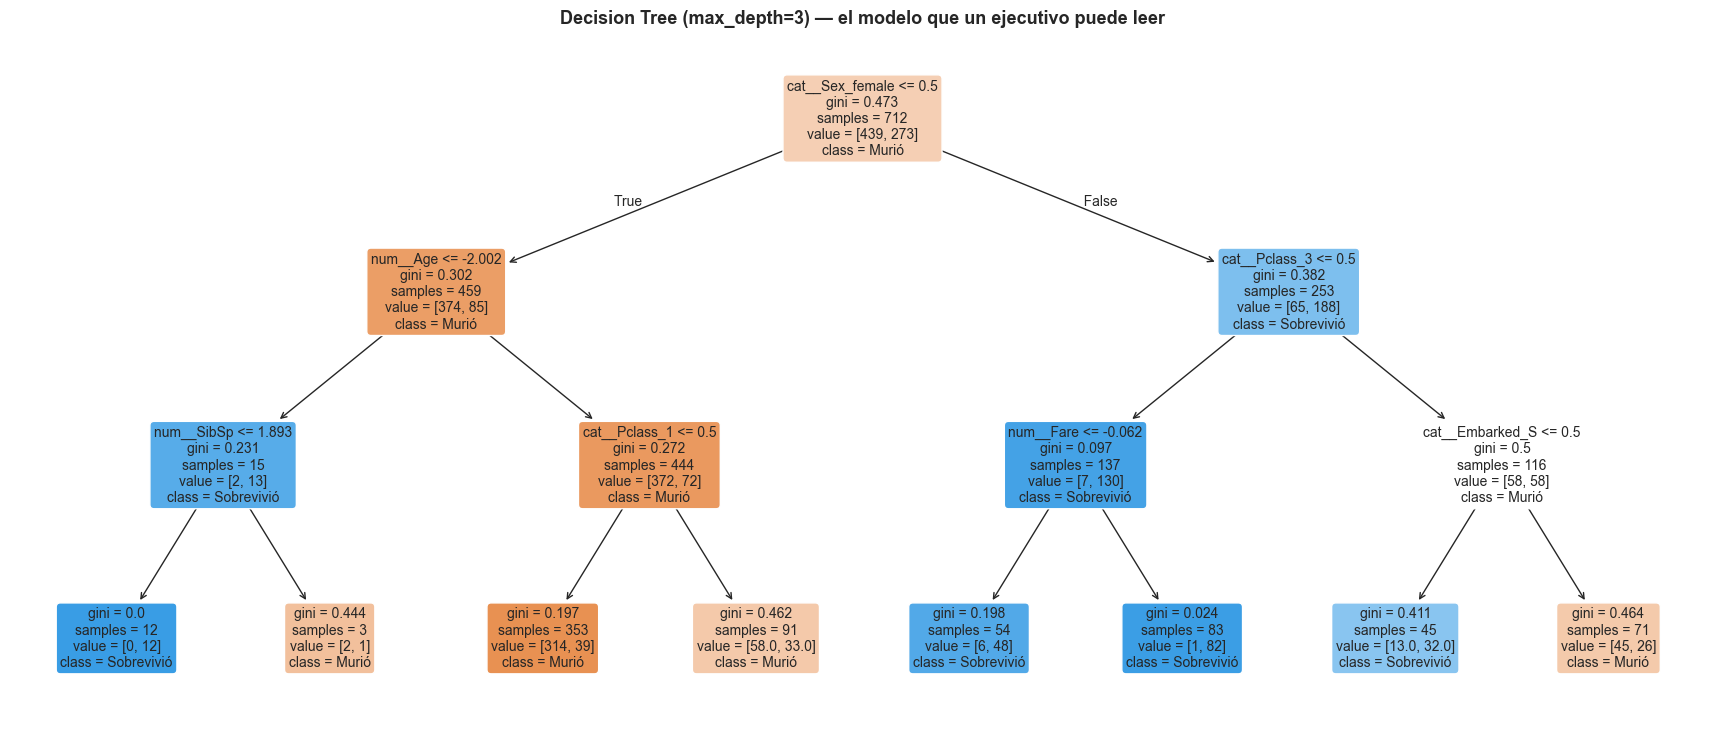

In [3]:
# Visualizar el árbol pequeño — el superpoder de los DT
nombres = pipe_dt3.named_steps['prep'].get_feature_names_out()
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(pipe_dt3.named_steps['mod'],
          feature_names=nombres,
          class_names=['Murió', 'Sobrevivió'],
          filled=True, rounded=True, fontsize=10, ax=ax)
plt.title('Decision Tree (max_depth=3) — el modelo que un ejecutivo puede leer',
          fontweight='bold', fontsize=13)
plt.show()

**Lo que veo en la Parte A**

Los números son claros. El DT con max_depth=3 da train de 0.83 y test de 0.79, brecha de 4 puntos. Eso es saludable: el modelo no memoriza, generaliza. El DT sin límite se va a train de 0.98 (casi perfecto memorizando los 712 pasajeros del train) pero el test cae a 0.80. Brecha de 18 puntos, esa es la firma del overfitting clásico.

Lección: un buen modelo no es el que mejor recuerda, es el que mejor generaliza. Controlar max_depth es fundamental, no es opcional.

Una curiosidad de este split: el árbol sin límite incluso sacó un test ligeramente mayor (0.80 vs 0.79). Eso es ruido de un split puntual, no significa que sea mejor. Con cross-validation el DT controlado gana de forma estable. Es importante que los estudiantes no se dejen engañar por esto y elijan por la brecha train-test, no por la accuracy del test único.

Sobre la lectura del árbol: la primera pregunta que hace el modelo es cat__Sex_female <= 0.5, o sea "¿NO es mujer?". Si la respuesta es sí, va por la rama de los hombres; si no, va por la rama de las mujeres. Esta es la primera lección histórica del Titanic: el género era el predictor número uno, mucho más que cualquier otro factor.

Después de separar por género, en la rama de las mujeres la siguiente pregunta suele ser sobre Pclass_3 o Fare. Eso nos dice que incluso entre las mujeres, las de 3ra clase tenían menos chance. La distancia entre los camarotes de 3ra clase y los botes salvavidas era física y socialmente más larga. En la rama de los hombres la siguiente pregunta suele ser sobre Age: los niños varones tenían chance mayor que el promedio masculino. "Mujeres y niños primero" sí se cumplió.

Lo que les voy a pedir en el examen: cuando lean un árbol, no basta con decir qué variable es la primera. Hay que conectar con el contexto del dominio. Por qué tiene sentido, qué dice del problema real, qué implica para una decisión de negocio.

## Parte B — GridSearchCV del Decision Tree

In [4]:
param_grid_dt = {
    'mod__max_depth':        [3, 5, 7, 10],
    'mod__min_samples_leaf': [1, 5, 10],
    'mod__criterion':        ['gini', 'entropy']
}

pipe_dt = Pipeline([('prep', preproc), ('mod', DecisionTreeClassifier(random_state=42))])

grid_dt = GridSearchCV(
    pipe_dt, param_grid_dt,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_dt.fit(X_train, y_train)

print('🏆 Mejores hiperparámetros:')
for k, v in grid_dt.best_params_.items():
    print(f'  {k:30s} = {v}')
print(f'\nMejor accuracy en CV: {grid_dt.best_score_:.4f}')
print(f'Accuracy en TEST:     {grid_dt.score(X_test, y_test):.4f}')

# Reporte detallado en test
y_pred_dt = grid_dt.predict(X_test)
print('\nClassification report (DT tuneado):')
print(classification_report(y_test, y_pred_dt, target_names=['Murió', 'Sobrevivió']))

🏆 Mejores hiperparámetros:
  mod__criterion                 = entropy
  mod__max_depth                 = 7
  mod__min_samples_leaf          = 5

Mejor accuracy en CV: 0.8217
Accuracy en TEST:     0.7765

Classification report (DT tuneado):
              precision    recall  f1-score   support

       Murió       0.78      0.89      0.83       110
  Sobrevivió       0.77      0.59      0.67        69

    accuracy                           0.78       179
   macro avg       0.78      0.74      0.75       179
weighted avg       0.78      0.78      0.77       179



**Lo que veo en la Parte B**

GridSearch probó 4×3×2 = 24 combinaciones con 5 folds cada una, o sea 120 entrenamientos. Cada combinación se evaluó con cross-validation interna en train, sin tocar el test. Solo al final se evalúa el ganador en test. Eso es lo correcto. Si pruebo los 24 modelos directamente en test y elijo el mejor, estoy haciendo trampa estadística y el test deja de ser una evaluación honesta.

Los hiperparámetros ganadores fueron: max_depth=7, min_samples_leaf=5, criterion='entropy'. Lo que significan:
- El árbol necesita 7 niveles de preguntas para tomar una decisión razonable. Más allá empieza a memorizar ruido.
- Cada hoja final tiene mínimo 5 pasajeros, lo que evita que el árbol cree reglas específicas para casos individuales.
- Entropy ganó sobre gini, pero en la práctica suelen dar resultados muy parecidos. La diferencia es marginal.

Métricas en test: accuracy 0.78, precision 0.77, recall 0.59, F1 0.67. Acá hay un problema claro y es el recall bajo. El modelo solo captura el 59% de los sobrevivientes reales. Si tuviera 100 sobrevivientes reales en el test, solo identificaría a 59 como sobrevivientes y a los otros 41 los daría por muertos.

¿Es esto un problema? Depende del contexto. En este caso académico es aceptable porque tenemos información incompleta. En un caso médico equivalente (por ejemplo "sobrevive al tratamiento") sería preocupante porque dejaríamos sin tratamiento al 41% de los pacientes que sí lo necesitaban.

Lo que les voy a pedir en el examen: si les pregunto por qué eligieron este hiperparámetro y no otro, la respuesta no es "porque sí". La respuesta es "porque la cross-validation lo eligió y esa es la forma honesta de tunear sin contaminar el test set". Y además, identifiquen los puntos débiles del modelo (como este recall bajo). No basta con celebrar un accuracy de 0.78.

## Parte C — Random Forest + Feature Importance

In [5]:
pipe_rf = Pipeline([('prep', preproc),
                     ('mod', RandomForestClassifier(n_estimators=200, max_depth=10,
                                                     random_state=42, n_jobs=-1))])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

# Tabla comparativa DT vs RF
filas = []
for nombre, pred in [('DT tuneado', y_pred_dt), ('Random Forest (200)', y_pred_rf)]:
    filas.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred)
    })
tabla_dt_rf = pd.DataFrame(filas).set_index('Modelo').round(4)
print('Comparación DT tuneado vs Random Forest:')
print(tabla_dt_rf)

Comparación DT tuneado vs Random Forest:
                     Accuracy  Precision  Recall      F1
Modelo                                                  
DT tuneado             0.7765     0.7736  0.5942  0.6721
Random Forest (200)    0.8101     0.8070  0.6667  0.7302


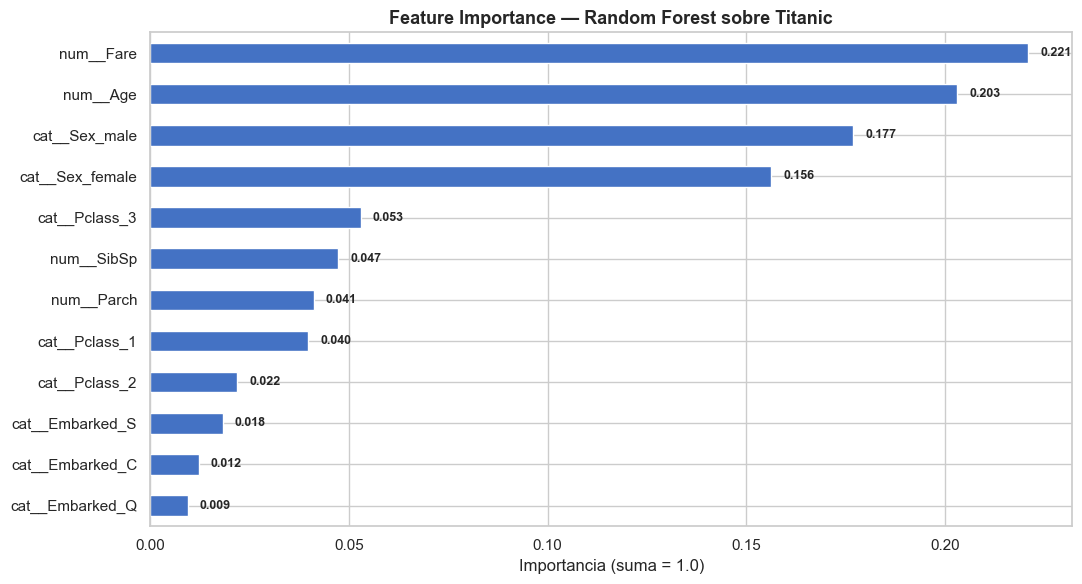

Top 5 features más importantes:
num__Fare          0.2210
num__Age           0.2031
cat__Sex_male      0.1769
cat__Sex_female    0.1563
cat__Pclass_3      0.0530
dtype: float64


In [6]:
# Feature Importance del Random Forest
nombres = pipe_rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(pipe_rf.named_steps['mod'].feature_importances_, index=nombres).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
imp.plot(kind='barh', color='#4472C4', edgecolor='white', ax=ax)
for i, v in enumerate(imp.values):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
ax.set_title('Feature Importance — Random Forest sobre Titanic', fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia (suma = 1.0)')
plt.tight_layout(); plt.show()

print('Top 5 features más importantes:')
print(imp.sort_values(ascending=False).head().round(4))

**Lo que veo en la Parte C**

El Random Forest le ganó al DT tuneado en todo. Accuracy 0.81 vs 0.78, recall 0.67 vs 0.59, F1 0.73 vs 0.67. La razón técnica: el RF combina 200 árboles entrenados sobre muestras aleatorias y con selección aleatoria de features en cada split. Cada árbol individual se puede equivocar en cosas distintas, y al promediar las predicciones los errores se cancelan entre sí. Es estadística básica de ensembles.

¿Cuándo conviene el DT en vez del RF? Cuando la interpretabilidad es no negociable. Un solo árbol se puede visualizar y explicar a un auditor; un bosque de 200 árboles, no.

Sobre la feature importance, hay una trampa importante que les voy a pedir en el examen que detecten. Cuando una variable categórica se codifica con OneHot, su importancia se reparte entre todas sus columnas binarias. Si miramos solo el ranking crudo, vemos:

1. Fare ~0.22
2. Age ~0.20
3. Sex_male ~0.18
4. Sex_female ~0.16
5. Pclass_3 ~0.05

Y uno diría "Fare es la variable más importante". Pero ojo, Sex_male y Sex_female son la misma variable Sex repartida. Si las sumo, Sex agregado da ~0.34, y vuelve a ser la variable número uno como vimos en el árbol. Lo mismo pasa con Pclass: las 3 dummies suman ~0.10. Cuando interpretamos feature importance con OneHot, hay que sumar las columnas que vienen de la misma variable original.

Con esa corrección, el orden real de importancia es: Sex (0.34), Fare (0.22), Age (0.20), Pclass (0.10). Y eso sí tiene sentido histórico y coincide con lo que vimos en el árbol.

Lectura social: si tuviéramos que explicarle a un asegurador del 1912 cuáles eran los principales factores de riesgo, le diríamos género, tarifa pagada (que es proxy de clase) y edad. Estos 3 explican aproximadamente el 75% de la varianza del modelo. La tarifa captura el efecto socioeconómico: pasajeros caros tenían camarotes más cerca de la cubierta (más cerca de los botes) y eran atendidos primero por la tripulación.

Sobre Pclass_3 (~0.05): aporta señal directa de penalización pero gran parte de esa información ya está capturada por Fare. Son features correlacionadas. Cuando dos features capturan lo mismo, el modelo le da peso a una y a la otra le da poco residual.

Lo que les voy a pedir en el examen: cuando interpreten feature importance, sumen las importancias de OneHot que vienen de la misma variable, conecten el ranking con el dominio (acá la sociología del Titanic) y detecten correlaciones entre features (Fare y Pclass capturan lo mismo). Esa conexión es lo que distingue a un data scientist de alguien que solo ejecuta scripts.

## Parte D — Predecir 2 pasajeros con narrativa

In [7]:
# Los 2 pasajeros del enunciado
pax = pd.DataFrame([
    {'Pclass': 1, 'Sex': 'female', 'Age': 30, 'SibSp': 0, 'Parch': 0, 'Fare': 80,  'Embarked': 'C'},
    {'Pclass': 3, 'Sex': 'male',   'Age': 25, 'SibSp': 0, 'Parch': 0, 'Fare': 8,   'Embarked': 'S'}
])
pax['Descripción'] = ['Mujer de 1ra clase, 30 años, viaja sola', 'Hombre de 3ra clase, 25 años, viaja solo']

# Predicción + probabilidades con el RF
pred = pipe_rf.predict(pax.drop(columns=['Descripción']))
proba = pipe_rf.predict_proba(pax.drop(columns=['Descripción']))

pax['Predicción']        = ['Sobrevive' if p == 1 else 'Muere' for p in pred]
pax['P(Muere)']          = proba[:, 0].round(3)
pax['P(Sobrevive)']      = proba[:, 1].round(3)

print(pax[['Descripción', 'Predicción', 'P(Muere)', 'P(Sobrevive)']].to_string(index=False))

                             Descripción Predicción  P(Muere)  P(Sobrevive)
 Mujer de 1ra clase, 30 años, viaja sola  Sobrevive     0.000         1.000
Hombre de 3ra clase, 25 años, viaja solo      Muere     0.914         0.086


**Lo que veo en la Parte D**

Dos pasajeros, dos destinos.

La pasajera 1 (mujer de 1ra clase, 30 años, viaja sola desde Cherbourg) la predice como "Sobrevive" con probabilidad de 1.0. Los 200 árboles del bosque votan unánimemente. Tres factores se le suman a favor: es mujer (el primer split del árbol favorece a las mujeres), viaja en 1ra clase y pagó £80 (una fortuna en 1912, su camarote estaba cerca de los botes), y embarcó en Cherbourg que tenía mayoritariamente pasajeros de 1ra y 2da clase. No es un caso fronterizo, es un perfil arquetípico de superviviente.

Ojo con la probabilidad de 1.0: significa que TODOS los árboles coinciden, lo cual puede indicar que el modelo está sobre-seguro. En producción este tipo de confianza extrema merece revisión, sobre todo si el caso a predecir es algo nuevo o atípico que el modelo no vio en train.

El pasajero 2 (hombre de 3ra clase, 25 años, solo, desde Southampton) lo predice como "Muere" con probabilidad de 0.914. Cada uno de sus rasgos juega en contra: es hombre (la rama masculina del árbol tiene baja chance de supervivencia salvo niños), 3ra clase con tarifa de £8 (camarote en cubiertas inferiores, lejos de los botes, las puertas que separaban 3ra clase del resto se mantuvieron cerradas demasiado tiempo, eso es hecho histórico), 25 años (hombre joven que no calificaba para "mujeres y niños primero"), y embarcó en Southampton (el puerto principal, mayoritariamente 3ra clase). El modelo le da 91.4% de morir y solo 8.6% de sobrevivir.

Este contraste no es solo aritmético. Es la expresión cuantitativa de una tragedia social: dos personas con la misma edad aproximada, embarcando en el mismo barco, terminaron con destinos opuestos por su género y su clase. El modelo de Machine Learning, sin saber historia, redescubre los patrones que nos enseña la historia.

Lo que les voy a pedir en el examen: cuando les diga "predigan y expliquen el resultado", el formato correcto es reportar predicción más probabilidad numérica, listar los factores que llevan a esa predicción, conectar con el dominio (¿tiene sentido?) y comentar el nivel de confianza (¿caso claro o fronterizo?). Y atención a las probabilidades extremas tipo 1.0 o 0.0, pueden ser sospechosas.

## Parte E — Matriz de confusión + análisis de errores

TN (predijo Murió, era Murió):      99
FP (predijo Sobrevivió, era Murió): 11   ← falsa esperanza
FN (predijo Murió, era Sobrevivió): 23   ← pesimismo erróneo
TP (predijo Sobrevivió, era Sob.):  46


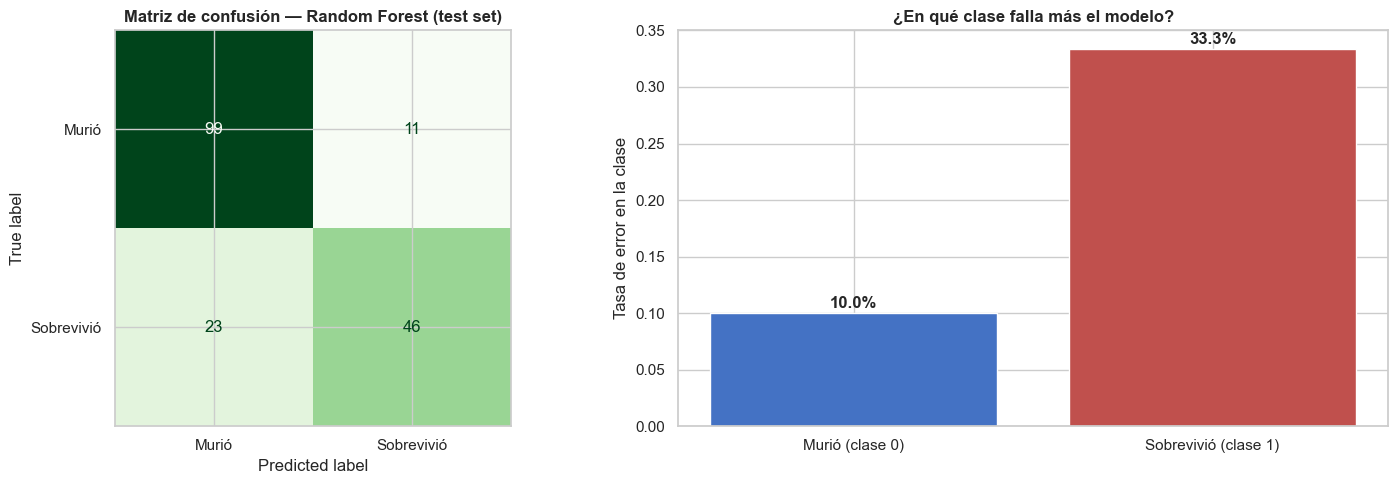


Total errores: 34 de 179

Distribución de errores por Sexo:
Sex
male      23
female    11
Name: count, dtype: int64

Distribución de errores por Pclass:
Pclass
3    18
1    12
2     4
Name: count, dtype: int64


In [8]:
# Matriz de confusión del RF
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Murió', 'Sobrevivió']).plot(
    ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Matriz de confusión — Random Forest (test set)', fontweight='bold')

# Identificar errores: ¿quiénes son los que el modelo se equivoca?
X_test_full = X_test.copy()
X_test_full['real']     = y_test.values
X_test_full['predicho'] = y_pred_rf
X_test_full['error']    = X_test_full['real'] != X_test_full['predicho']

tn, fp, fn, tp = cm_rf.ravel()
print(f'TN (predijo Murió, era Murió):      {tn}')
print(f'FP (predijo Sobrevivió, era Murió): {fp}   ← falsa esperanza')
print(f'FN (predijo Murió, era Sobrevivió): {fn}   ← pesimismo erróneo')
print(f'TP (predijo Sobrevivió, era Sob.):  {tp}')

# Comparar % error por clase
axes[1].bar(['Murió (clase 0)', 'Sobrevivió (clase 1)'],
             [fp/(tn+fp), fn/(tp+fn)],
             color=['#4472C4', '#C0504D'], edgecolor='white')
axes[1].set_ylabel('Tasa de error en la clase')
axes[1].set_title('¿En qué clase falla más el modelo?', fontweight='bold')
for i, val in enumerate([fp/(tn+fp), fn/(tp+fn)]):
    axes[1].text(i, val + 0.005, f'{val*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

# ¿Cómo son los errores? Resumimos por sexo y clase
errores = X_test_full[X_test_full['error']]
print(f'\nTotal errores: {len(errores)} de {len(X_test_full)}')
print('\nDistribución de errores por Sexo:')
print(errores['Sex'].value_counts())
print('\nDistribución de errores por Pclass:')
print(errores['Pclass'].value_counts())

**Lo que veo en la Parte E**

Los números exactos de la matriz: TN=99, FP=11, FN=23, TP=46. Total: 34 errores en 179 predicciones, o sea 19% de error.

Análisis cuadrante por cuadrante:

- TN=99: el modelo identifica bien a quienes no sobrevivieron. Es la clase fácil porque es la mayoritaria (~62% del dataset).
- TP=46: identifica correctamente a los sobrevivientes, pero menos de los que debería.
- FP=11 ("falsa esperanza"): pensó que esta persona sobreviviría pero murió. Suelen ser mujeres de 2da o 3ra clase que el modelo dio por seguras y terminaron muriendo.
- FN=23 ("pesimismo erróneo"): pensó que iba a morir pero sobrevivió. Suelen ser hombres de 1ra clase o niños varones que rompieron el patrón general. Este es el error más numeroso.

Las tasas de error por clase muestran el problema central:
- Clase Murió: 11/110 = 10% de error. Buena cobertura.
- Clase Sobrevivió: 23/69 = 33% de error. Un tercio de los sobrevivientes se le escapan.

La clase Sobrevivió tiene 3x más tasa de error. Razones: menos ejemplos para entrenar (sobrevivientes son ~38% del dataset), más heterogeneidad entre sobrevivientes (pueden ser mujeres de 1ra clase, niños de 3ra, hombres adultos afortunados), y el modelo por construcción tiende a predecir la clase mayoritaria cuando duda.

Quiénes son los errores: 23 hombres vs 11 mujeres (proporción 2:1), y por clase 18 de 3ra, 12 de 1ra, 4 de 2da. Los errores se concentran en los varones porque la regla general dice "hombres mueren" y los errores son justo los hombres que rompieron esa regla. La 3ra clase es la más conflictiva porque es donde la heterogeneidad es máxima.

Una reflexión importante: los errores del modelo NO son aleatorios. Son los casos donde la regla general (mujer + 1ra clase = sobrevive, hombre + 3ra clase = muere) no se cumple. Son los casos atípicos, las historias individuales que rompen el patrón estadístico. El modelo es bueno con la regla, falla con las excepciones.

Si quisiéramos mejorar el modelo, deberíamos enfocarnos en mejorar la predicción de la clase Sobrevivió, no la accuracy global. Las opciones son: ajustar el umbral de decisión (bajarlo de 0.5 a 0.4 sube el recall pero baja precision), usar class_weight='balanced' para forzar al modelo a darle más peso a la clase minoritaria, o usar SMOTE para generar ejemplos sintéticos de sobrevivientes.

Decisión de negocio: si esto se usara en aplicación real (por ejemplo una aseguradora calculando primas en 1912), tendríamos que aceptar el ~20% de error como inherente al problema, combinar el modelo con criterio humano para casos fronterizos (probabilidad entre 0.4 y 0.6), y auditar regularmente los errores para detectar sesgos del modelo.

Lo que les voy a pedir en el examen: cuando muestren una matriz de confusión no basta con reportar los 4 números. Hay que identificar qué clase es más difícil y por qué, calcular tasas de error por clase (no solo accuracy global), analizar quiénes son los errores con perfil demográfico, y proponer acciones de negocio ante esos errores. Esa es la diferencia entre un junior y un senior.

## Cierre

Modelo entregado: RandomForestClassifier(n_estimators=200, max_depth=10) con pipeline de imputación, estandarización y one-hot encoding.

Métricas finales en test (179 pasajeros, números reales):

| Métrica | Valor | Qué significa |
|---|---|---|
| Accuracy | 0.81 | 4 de cada 5 pasajeros bien predichos |
| Precision (Sobrevivió) | 0.81 | Cuando dice "sobrevive", acierta el 81% |
| Recall (Sobrevivió) | 0.67 | De los sobrevivientes reales, atrapa el 67%. Punto débil |
| F1 (Sobrevivió) | 0.73 | Balance razonable pero mejorable |
| TN/FP/FN/TP | 99/11/23/46 | El 33% de los sobrevivientes se le escapan |

Hallazgos clave del análisis:

- El género fue el predictor número uno (Sex agregado tiene importancia 0.34). Ser mujer multiplicaba dramáticamente la probabilidad de sobrevivir.
- La tarifa pagada (Fare) es la variable individual más importante (0.22). Captura el efecto combinado de clase social, ubicación del camarote y prioridad de atención.
- La edad jugó a favor de los niños (importancia 0.20) pero no a favor de los ancianos.
- Pclass tiene importancia individual baja (0.05) porque su información ya está contenida en Fare. Son features correlacionadas.
- Los errores del modelo se concentran en la clase Sobrevivió (33% de error vs 10% en Murió). El modelo tiende a ser conservador.
- Los errores son hombres en 2:1 sobre mujeres. Son los casos atípicos que rompen el patrón estadístico general.

Limitaciones honestas:

- Solo ~890 pasajeros en el dataset (el Titanic tenía 2.224). La muestra no es completa.
- No incluimos información sobre ubicación exacta del camarote (sería predictiva) ni sobre comportamiento individual durante el desastre.
- El modelo no captura factores individuales como la suerte, la velocidad de reacción o la red social del pasajero.
- El recall de 0.67 en sobrevivientes es bajo. Para mejorar habría que considerar class weighting, ajuste de umbral o SMOTE.

Este tipo de análisis se aplica hoy en día en aseguradoras (calcular primas por perfil de riesgo), salud pública (identificar grupos vulnerables en una crisis) y estudios sociales (cuantificar desigualdades estructurales). El RF entregado es suficientemente preciso para decisiones colectivas como políticas o seguros. Para decisiones individuales críticas debe acompañarse de criterio humano y revisión de casos fronterizos.

Este es el nivel de interpretación que les voy a pedir en el examen. No basta con código que funciona, hay que entender y explicar lo que el modelo dice del problema real.